<a href="https://colab.research.google.com/github/Imparth2803/machine_learning/blob/Clustering/k_means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
%matplotlib inline

In [6]:
X,y =make_blobs(n_samples= 1000, centers=3,n_features=2, random_state=23)

In [7]:
X.shape

(1000, 2)

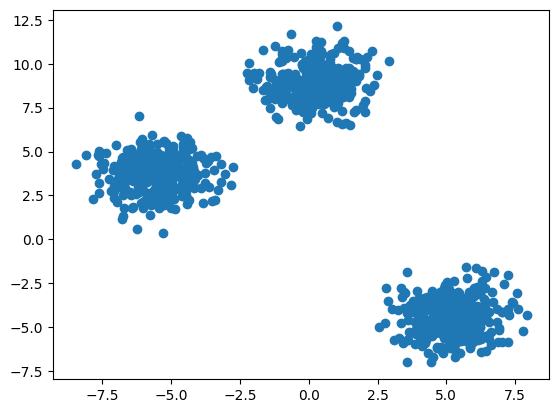

In [9]:
plt.scatter(X[:,0],X[:,1])

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [11]:
from sklearn.cluster import KMeans

In [12]:
# Elbow method to select the K value

wcss = []
for k in range(1,11):
  kmeans =KMeans(n_clusters=k, init ='k-means++')
  kmeans.fit(X_train)
  wcss.append(kmeans.inertia_)

In [13]:
wcss

[34827.576825520235,
 7935.437286145425,
 1319.2730531585605,
 1184.0746504428382,
 1108.9234752673574,
 902.836083907814,
 763.1074779393082,
 678.7086694565495,
 578.2629834771545,
 535.6917412627092]

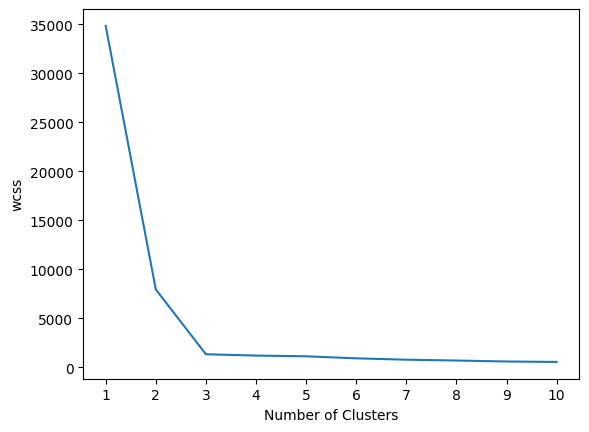

In [14]:
#plot elbow curve

plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel('Number of Clusters')
plt.ylabel('wcss')
plt.show()

In [15]:
kmeans = KMeans(n_clusters=3, init='k-means++')

In [16]:
y_labels = kmeans.fit_predict(X_train)

In [18]:
kmeans.predict(X_test)

array([2, 2, 2, 0, 1, 2, 0, 0, 1, 0, 2, 2, 1, 0, 2, 0, 0, 2, 1, 2, 2, 2,
       0, 2, 2, 0, 1, 2, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 2, 1, 1, 2,
       0, 1, 0, 2, 2, 0, 1, 2, 0, 2, 1, 2, 2, 2, 1, 1, 1, 2, 2, 2, 2, 0,
       0, 2, 1, 1, 2, 2, 1, 0, 0, 2, 0, 0, 2, 2, 1, 1, 0, 1, 0, 0, 1, 2,
       0, 2, 1, 2, 1, 2, 1, 0, 2, 0, 1, 0, 0, 1, 2, 0, 1, 0, 1, 1, 0, 0,
       1, 1, 0, 1, 0, 1, 1, 2, 1, 1, 1, 1, 0, 1, 0, 0, 1, 2, 1, 0, 1, 2,
       2, 1, 0, 1, 2, 0, 2, 2, 1, 1, 1, 2, 1, 1, 0, 0, 0, 0, 2, 1, 1, 2,
       2, 1, 2, 2, 0, 0, 2, 2, 0, 0, 1, 2, 0, 0, 2, 2, 2, 1, 2, 2, 1, 1,
       1, 0, 0, 2, 0, 1, 0, 2, 1, 1, 0, 1, 0, 2, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 0, 2, 2, 0, 2, 0, 1, 0, 0, 1, 2, 1, 2, 2, 2, 2, 2, 1, 2, 2, 1,
       0, 2, 1, 0, 1, 2, 2, 1, 2, 2, 2, 2, 1, 0, 1, 1, 0, 2, 0, 2, 1, 2,
       2, 1, 2, 0, 2, 2, 1, 2, 0, 0, 0, 2, 0, 1, 2, 2, 0, 2, 0, 0, 0, 2,
       0, 1, 2, 0, 0, 1, 0, 1, 1, 1, 0, 2, 1, 2, 1, 0, 0, 0, 2, 2, 0, 0,
       2, 0, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 0, 0, 2,

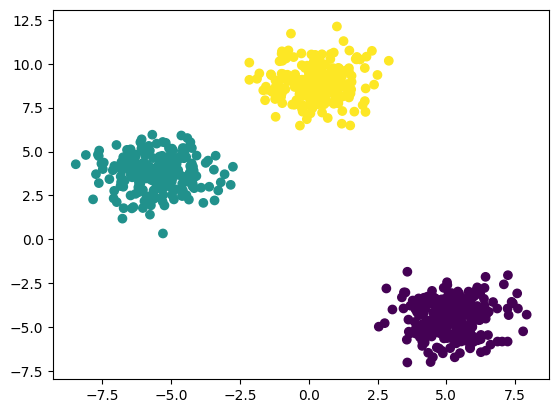

In [17]:
plt.scatter(X_train[:,0],X_train[:,1], c=y_labels)

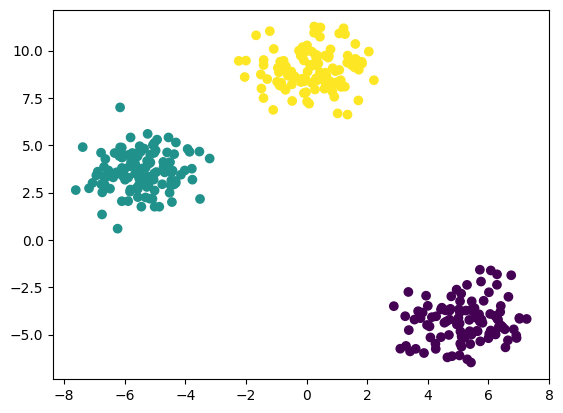

In [23]:
y_test_label = kmeans.predict(X_test)
plt.scatter(X_test[:,0],X_test[:,1], c=y_test_label)

In [25]:
#performance metrics
#silhouette Score
from sklearn.metrics import silhouette_score

In [26]:
silhouette_coefficients = []
for k in range(2,11):
  kmeans = KMeans(n_clusters=k, init='k-means++')
  kmeans.fit(X_train)
  score = silhouette_score(X_train, kmeans.labels_)
  silhouette_coefficients.append(score)

In [27]:
silhouette_coefficients

[np.float64(0.7281443868598331),
 np.float64(0.8071181203797672),
 np.float64(0.6357733426488265),
 np.float64(0.47876503743578985),
 np.float64(0.3321994964555899),
 np.float64(0.33513622835934276),
 np.float64(0.3070526547854192),
 np.float64(0.33964649283403475),
 np.float64(0.3310053471709806)]

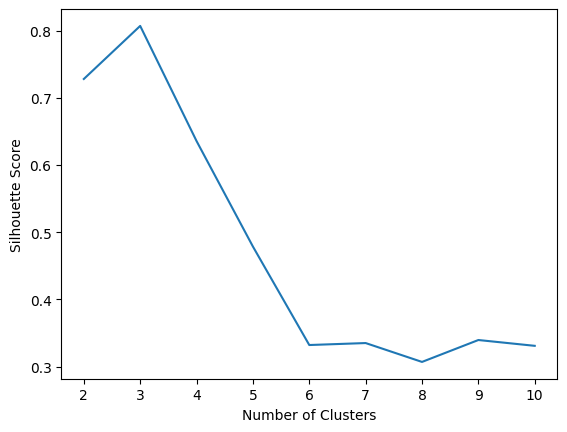

In [28]:
#plotting Silhouette score
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.show()